# Iterative workflow with LLM in LANGGRAPH


In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Literal, Annotated
from dotenv import load_dotenv
from langchain_core.output_parsers import JsonOutputParser
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from langchain_core.messages import SystemMessage,HumanMessage
import operator
from pydantic import BaseModel,Field
load_dotenv()

c:\Coding\Python\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
c:\Coding\Python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [3]:
llm=HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b",
    task="text-generation"
)

model=ChatHuggingFace(llm=llm)

In [4]:
class TweetEvaluaton(BaseModel):
    evaluation:Literal["approved","Need_Improvement"]=Field(description='Final evaluation result.')
    feedback:str=Field(description="feedback for the tweet.")

In [5]:
parser=JsonOutputParser(
    pydantic_object=TweetEvaluaton
)

In [6]:
class TweetState(TypedDict):
    topic:str
    tweet:str
    evaluation:Literal["approved","need_improvement"]
    feedback:str
    iteration:int
    max_iteration:int

    tweet_history:Annotated[list[str],operator.add]
    feedback_history:Annotated[list[str],operator.add]

In [7]:
def generate_tweet(state:TweetState)->TweetState:
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response=model.invoke(messages)
    # output=parser.parse(response.content)

    return{
        'tweet':response.content,
        'tweet_history':[response.content]
    }

In [ ]:
# def generate_tweet(state: TweetState) -> TweetState:

#     messages = [
#         SystemMessage(content="""
# You are a viral Twitter writer.

# Your task is to write short, witty, original tweets.

# Rules:
# - Maximum 280 characters
# - Avoid generic motivation
# - Avoid question-answer joke formats
# - Avoid setup-punchline comedy structure
# - Keep it sharp, punchy, and scroll-stopping
# - Make it feel like a real viral tweet
# - One tweet only
# - No hashtags unless truly necessary
# - No emojis unless they genuinely improve humor
# """),

#         HumanMessage(content=f"""
# Topic: {state['topic']}

# Previous feedback:
# {state.get('feedback', 'None')}

# Write a better tweet.
# """)
#     ]

#     response = model.invoke(messages)

#     return {
#         "tweet": response.content.strip()
#     }

In [22]:
# def generate_tweet(state:TweetState)->TweetState:
#     messages = [
#         SystemMessage(content="You are a funny and clever Twitter/x influencer."),
#         HumanMessage(content=f"""
# Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

# Rules:
# - Do NOT use question-answer format.
# - Max 280 characters.
# - Use observational humor, irony, sarcasm, or cultural references.
# - Think in meme logic, punchlines, or relatable takes.
# - Use simple, day to day english
# """)
#     ]

#     response=model.invoke(messages)

#     return{
#         'tweet': response.content,
#         'tweet_history':[response.content]
#     }

In [13]:
# def evaluate_tweet(state:TweetState)->TweetState:
#     format_instructions = parser.get_format_instructions()
#     messages = [
#         SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
#         HumanMessage(content=f"""
# Evaluate the following tweet:

# Tweet: "{state['tweet']}"

# Use the criteria below to evaluate the tweet:

# 1. Originality – Is this fresh, or have you seen it a hundred times before?  
# 2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
# 3. Punchiness – Is it short, sharp, and scroll-stopping?  
# 4. Virality Potential – Would people retweet or share it?  
# 5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

# Auto-reject if:
# - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
# - It exceeds 280 characters
# - It reads like a traditional setup-punchline joke
# - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

# Respond only in valid JSON.

# {format_instructions}
# """)
#     ]

#     response=model.invoke(messages)
#     output=parser.parse(response.content)
#     return{
#         'evaluation': output['evaluation'],
#         'feedback': output['feedback'],
#         'feedback_history': [output['feedback']]
#     }


In [14]:
def evaluate_tweet(state: TweetState) -> TweetState:

    format_instructions = parser.get_format_instructions()

    messages = [
        SystemMessage(content="""
You are a ruthless, no-laugh-given Twitter critic.

You judge tweets like a top viral content editor.

Be extremely honest.
Approve only genuinely strong tweets.
"""),

        HumanMessage(content=f"""
Evaluate the following tweet:

Tweet:
"{state['tweet']}"

Use the criteria below:

1. Originality
- Is this fresh or overused?

2. Humor
- Is it genuinely funny or clever?

3. Punchiness
- Is it short, sharp, and attention-grabbing?

4. Virality Potential
- Would people repost or quote it?

5. Format
- Does it feel like a real tweet?

Auto reject if:
- It exceeds 280 characters
- It feels generic
- It uses setup-punchline joke structure
- It feels like AI-generated fluff
- It ends weakly

Respond ONLY in valid JSON.

{format_instructions}
""")
    ]

    response = model.invoke(messages)

    output = parser.parse(response.content)

    return {
        "evaluation": output["evaluation"],
        "feedback": output["feedback"],
        "feedback_history": [output["feedback"]]
    }

In [25]:
# def evaluate_tweet(state:TweetState)->TweetState:

#     format_instructions = parser.get_format_instructions()

#     messages = [
#         SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
        
#         HumanMessage(content=f"""
# Evaluate the following tweet:

# Tweet: "{state['tweet']}"

# Use the criteria below to evaluate the tweet:

# 1. Originality
# 2. Humor
# 3. Punchiness
# 4. Virality Potential
# 5. Format

# Respond only in valid JSON.

# {format_instructions}
# """)
#     ]

#     response=model.invoke(messages)

#     output=parser.parse(response.content)

#     return{
#         'evaluation': output['evaluation'],
#         'feedback': output['feedback'],
#         'feedback_history':[output['feedback']]
#     }

In [9]:
def optimize_tweet(state:TweetState)->TweetState:
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response=model.invoke(messages)

    iteration=state['iteration']+1

    return{
        'tweet': response.content,
        'iteration': iteration,
        'tweet_history': [response.content]
}


In [10]:
def route_evaluation(state:TweetState):
    if state['evaluation']=='approved' or state['iteration']>=state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

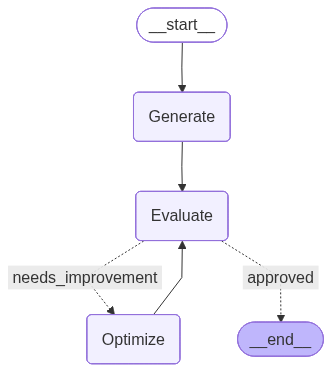

In [11]:
graph=StateGraph(TweetState)

graph.add_node("Generate",generate_tweet)
graph.add_node("Evaluate",evaluate_tweet)
graph.add_node("Optimize",optimize_tweet)

graph.add_edge(START,"Generate")
graph.add_edge("Generate","Evaluate")
graph.add_conditional_edges("Evaluate",route_evaluation,{'approved':END,'needs_improvement':"Optimize"})
graph.add_edge("Optimize","Evaluate")

workflow=graph.compile()
workflow

In [15]:
initial_state={
    "topic": "srhberhb",
    "iteration": 1,
    "max_iteration": 5
}
result=workflow.invoke(initial_state)

In [16]:
result

{'topic': 'srhberhb',
 'tweet': 'Just spent 5\u202fminutes trying to decode my own brainwave:\u202fsrhberhb. Turns out it’s the new corporate buzzword for “I have no idea what I’m doing but I’m typing anyway.” #MondayMotivation #KeyboardFail',
 'evaluation': 'approved',
 'feedback': 'Originality: fairly fresh with the fake buzzword angle. Humor: decent chuckle, the brain‑wave joke lands. Punchiness: concise enough, hashtags help scroll‑stop. Virality: good share potential among office‑culture folks. Format: well‑formed tweet under 280 chars.',
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['Just spent 5\u202fminutes trying to decode my own brainwave:\u202fsrhberhb. Turns out it’s the new corporate buzzword for “I have no idea what I’m doing but I’m typing anyway.” #MondayMotivation #KeyboardFail'],
 'feedback_history': ['Originality: fairly fresh with the fake buzzword angle. Humor: decent chuckle, the brain‑wave joke lands. Punchiness: concise enough, hashtags help scroll‑st